In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
pd.set_option("display.max_columns", None)

In [2]:
df=pd.read_csv('datos_limpios.csv')
df.head(3)

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID,ANIO_CONSTRUCCION_FINAL
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,True,False,False,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3.0,1.0,1965,5,22,7.0,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3,1965
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,False,True,True,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.0,1.0,1967,6,79,6.0,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3,1967
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,True,True,True,3,False,False,False,True,True,True,False,True,False,False,False,False,False,False,2.0,1.0,1955,4,15,6.0,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3,1955


In [3]:
correlaciones=df.corr(numeric_only=True).round(2)

In [4]:
df['CADASTRALQUALITYID'].max()

np.float64(9.0)

<Axes: xlabel='ANIO_CONSTRUCCION_FINAL', ylabel='Count'>

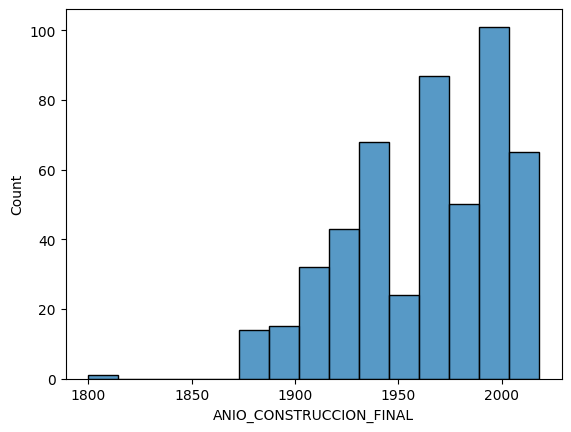

In [5]:
sns.histplot(
    x='ANIO_CONSTRUCCION_FINAL',
    data=df[df['CADASTRALQUALITYID']==0]
)

In [6]:
df[df['CADASTRALQUALITYID']==0]['PRICE']

342       1061000
344         98000
413       1160000
441        218000
447        226000
           ...   
187312    2404000
187319    2751000
187330    1102000
187376    2787000
188249     857000
Name: PRICE, Length: 500, dtype: int64

<Axes: xlabel='CADASTRALQUALITYID', ylabel='UNITPRICE'>

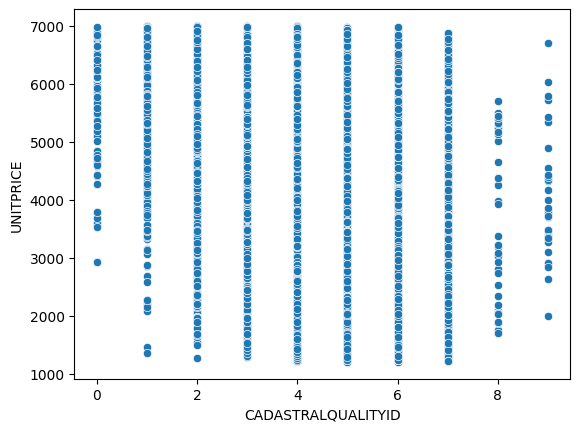

In [7]:
sns.scatterplot(
    x='CADASTRALQUALITYID',
    y='UNITPRICE',
    data=df[df['CITYNAME']=='Barcelona']
)

In [8]:
df[df['CADASTRALQUALITYID']==0].describe().round(2)

,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,AMENITYID,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,BUILTTYPEID,ANIO_CONSTRUCCION_FINAL
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,466.00,457.00,500.00,500.00,500.00,500.0,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,201808.13,1169352.00,6015.82,185.94,3.00,2.31,2.91,3.62,1.16,1963.94,12.68,72.74,0.0,2.29,0.31,1.10,-2.37,40.57,2.80,1963.94
std,3.81,1304993.16,1925.33,165.00,1.64,1.35,0.37,2.91,0.36,37.09,8.16,95.33,0.0,1.38,0.20,0.90,2.37,0.46,0.44,37.09
min,201803.00,79000.00,866.67,30.00,0.00,1.00,1.00,-1.00,1.00,1800.00,1.00,1.00,0.0,0.05,0.01,0.02,-3.75,39.46,1.00,1800.00
25%,201803.00,465750.00,4794.13,84.75,2.00,1.00,3.00,2.00,1.00,1940.00,7.00,14.00,0.0,1.35,0.19,0.29,-3.69,40.42,3.00,1940.00
50%,201809.00,725500.00,6046.18,129.50,3.00,2.00,3.00,3.00,1.00,1971.00,9.00,20.00,0.0,2.08,0.26,1.03,-3.68,40.43,3.00,1971.00
75%,201812.00,1270750.00,7158.70,220.00,4.00,3.00,3.00,5.00,1.00,2000.00,23.00,102.00,0.0,2.62,0.36,1.52,-3.67,40.44,3.00,2000.00
max,201812.00,7124000.00,9997.56,951.00,18.00,7.00,3.00,11.00,2.00,2018.00,27.00,339.00,0.0,9.59,1.67,5.40,2.22,41.41,3.00,2018.00


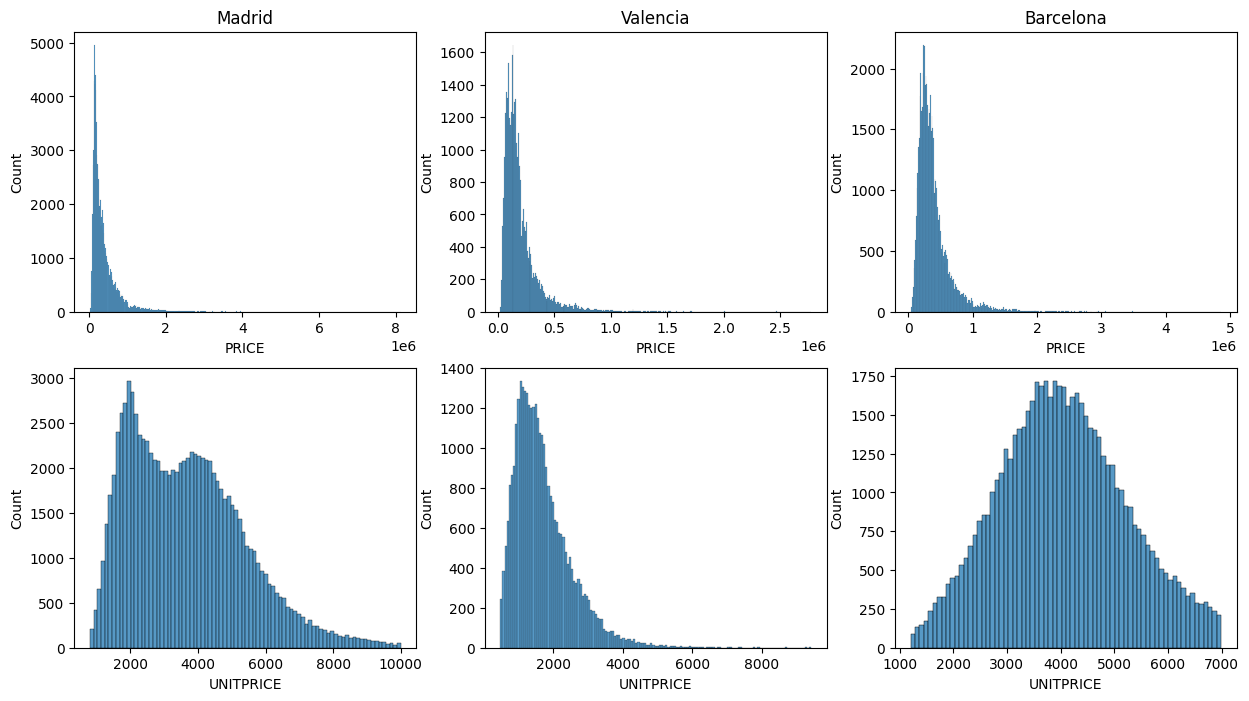

In [9]:
ciudades=df['CITYNAME'].unique()
columnas=['PRICE','UNITPRICE']
plt.figure(figsize=(15,8))
for i,ciudad in enumerate(ciudades):
    for j,columna in enumerate(columnas):
        plt.subplot(2,len(ciudades),i+(1+j*len(ciudades)))
        dfciudad=df[df['CITYNAME']==ciudad]
        sns.histplot(
            x=columna,
            log_scale=False,
            data=dfciudad
        )
        if (j==0):
            plt.title(ciudad)
plt.show()
# unitprice es más normal que price, pero en escala logarítmica price es más normal que unitprice

In [10]:
correlaciones['BATHNUMBER'].sort_values(ascending=False)

BATHNUMBER                       1.00
CONSTRUCTEDAREA                  0.74
PRICE                            0.68
ROOMNUMBER                       0.54
HASPARKINGSPACE                  0.32
ISPARKINGSPACEINCLUDEDINPRICE    0.32
HASLIFT                          0.29
HASDOORMAN                       0.29
UNITPRICE                        0.25
HASBOXROOM                       0.25
HASSWIMMINGPOOL                  0.21
HASGARDEN                        0.19
HASWARDROBE                      0.19
HASTERRACE                       0.16
CADMAXBUILDINGFLOOR              0.16
HASAIRCONDITIONING               0.15
CADCONSTRUCTIONYEAR              0.12
FLOORCLEAN                       0.12
ISDUPLEX                         0.12
ANIO_CONSTRUCCION_FINAL          0.12
CADDWELLINGCOUNT                 0.08
DISTANCE_TO_METRO                0.07
HASSOUTHORIENTATION              0.06
HASWESTORIENTATION               0.05
HASEASTORIENTATION               0.04
HASNORTHORIENTATION              0.03
ISINTOPFLOOR

<Axes: xlabel='PRICE', ylabel='LATITUDE'>

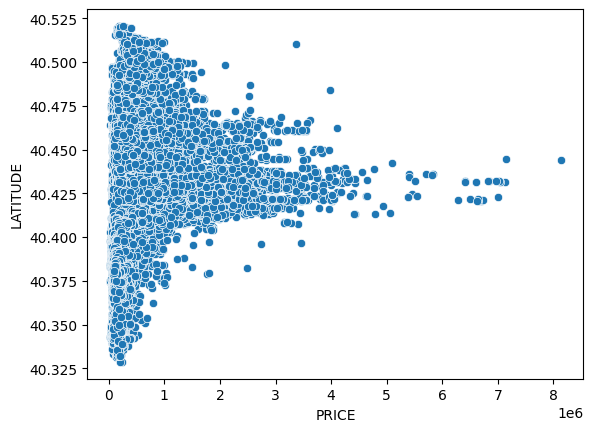

In [11]:
sns.scatterplot(
    x='PRICE',
    y='LATITUDE',
    data=df[df['CITYNAME']=='Madrid']
)

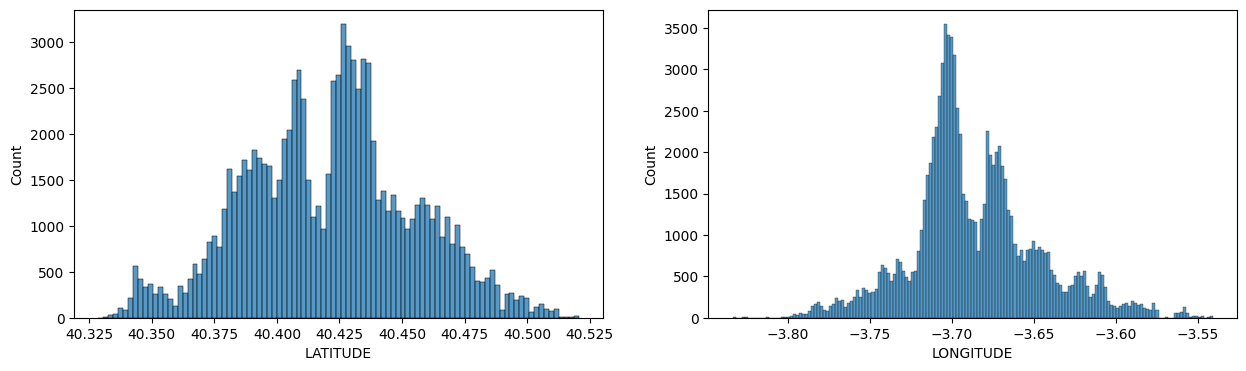

In [12]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.histplot(
    x='LATITUDE',
    data=df[df['CITYNAME']=='Madrid']
)
plt.subplot(1,2,2)
sns.histplot(
    x='LONGITUDE',
    data=df[df['CITYNAME']=='Madrid']
)
plt.show()

In [13]:
for ciudad in ciudades:
    statistic,pvalue=stats.shapiro(df[df['CITYNAME']==ciudad].sample(1000)['UNITPRICE'])
    print(f"{ciudad}: {statistic} {pvalue} Normal={pvalue>0.05}")

Madrid: 0.9550175304897212 5.933328361432933e-17 Normal=False
Valencia: 0.9012400519895206 7.131455573619594e-25 Normal=False
Barcelona: 0.993469567692151 0.00022791950348659937 Normal=False


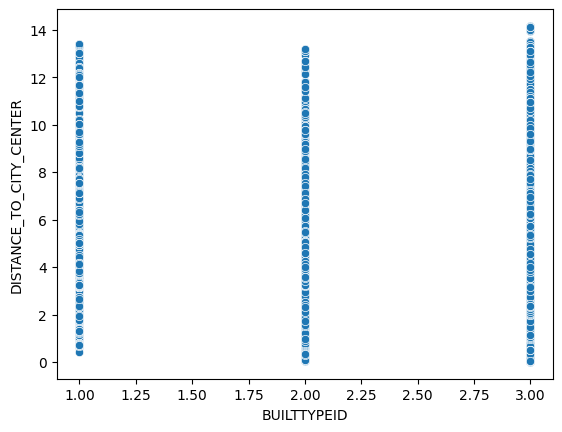

In [14]:
sns.scatterplot(
    x='BUILTTYPEID',
    y='DISTANCE_TO_CITY_CENTER',
    data=df
)
plt.show()
#los pisos de tipo 3 llegan a precios más altos que los de tipo 1, los de tipo dos están en un nivel intermedio
#todos lo que tienen espacio de parking tienen el espacio de parking incluído en el precio

In [15]:
df[(~df['HASPARKINGSPACE']) & (~df['ISPARKINGSPACEINCLUDEDINPRICE'])]

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID,ANIO_CONSTRUCCION_FINAL
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,True,False,False,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3.0,1.0,1965,5,22,7.0,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3,1965
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,False,True,True,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.0,1.0,1967,6,79,6.0,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3,1967
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,True,True,True,3,False,False,False,True,True,True,False,True,False,False,False,False,False,False,2.0,1.0,1955,4,15,6.0,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3,1955
3,A12032801997263349694,201812,126000,1680.000000,75,3,1,True,True,True,3,False,False,True,True,False,False,False,True,False,False,True,False,False,False,2.0,1.0,1971,5,11,6.0,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,3,1971
4,A16032891972289007994,201803,184000,1840.000000,100,3,2,True,True,True,3,False,False,False,False,False,False,False,True,False,True,False,False,False,False,1.0,1.0,1968,5,15,6.0,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,3,1968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189917,A5469264850873866443,201809,72000,1142.857143,63,2,1,False,False,False,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,3.0,1.0,1968,5,11,6.0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,2,1968
189918,A711055539203140082,201809,136000,1360.000000,100,3,2,True,False,True,3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,3.0,1.0,1987,7,29,5.0,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,3,1987
189919,A4740286493963203916,201812,119000,1676.056338,71,3,1,False,False,False,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.0,NaN,1955,4,17,5.0,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,3,1955
189920,A15722582369407807529,201809,96000,1500.000000,64,3,1,True,True,False,3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,3.0,2.0,1970,7,21,6.0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,2,1970


<Axes: xlabel='CONSTRUCTEDAREA', ylabel='PRICE'>

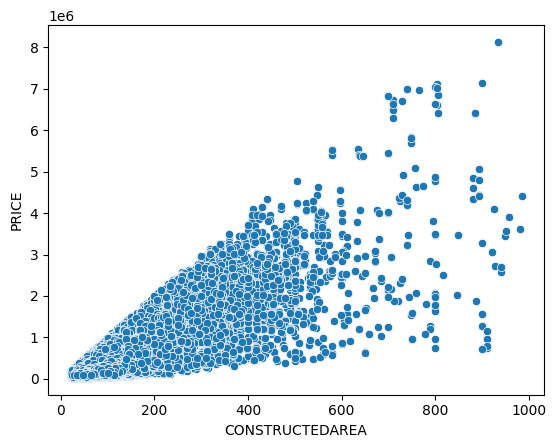

In [16]:
sns.scatterplot(
    x='CONSTRUCTEDAREA',
    y='PRICE',
    data=df
)

In [17]:
df=df.assign(
    log_precio=df['PRICE'].map(np.log1p),
    log_superficie=df['CONSTRUCTEDAREA'].map(np.log1p)
).dropna(subset=['log_precio','log_superficie'])

In [18]:
x:pd.DataFrame=df[['log_superficie']]
y:pd.Series=df['log_precio']

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [20]:
model:LinearRegression=LinearRegression()
model.fit(x_train,y_train)
yhat=model.predict(x_test)
print(f"MAE: {mean_absolute_error(y_test,yhat)}")
print(f"MSE: {mean_squared_error(y_test,yhat)}")
print(f"RMSE: {root_mean_squared_error(y_test,yhat)}")
print(f"R2: {r2_score(y_test,yhat)}")

MAE: 0.44267337470439133
MSE: 0.29259079487222656
RMSE: 0.540916624695735
R2: 0.46186381015780265


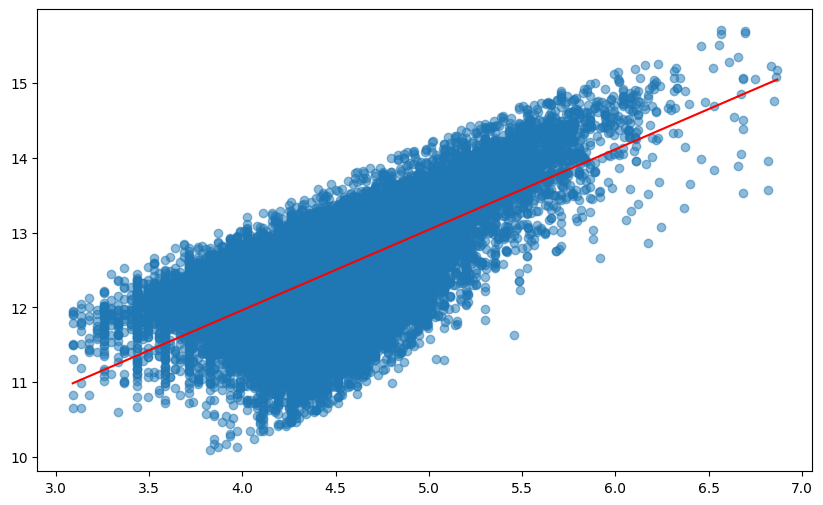

In [21]:
orden=x_test.iloc[:,0].argsort()
x_test_sorted=x_test.iloc[orden]
yhat_sorted=yhat[orden]
plt.figure(figsize=(10,6))
plt.scatter(x_test,y_test,alpha=0.5)
plt.plot(x_test_sorted,yhat_sorted,color='red')
plt.show()

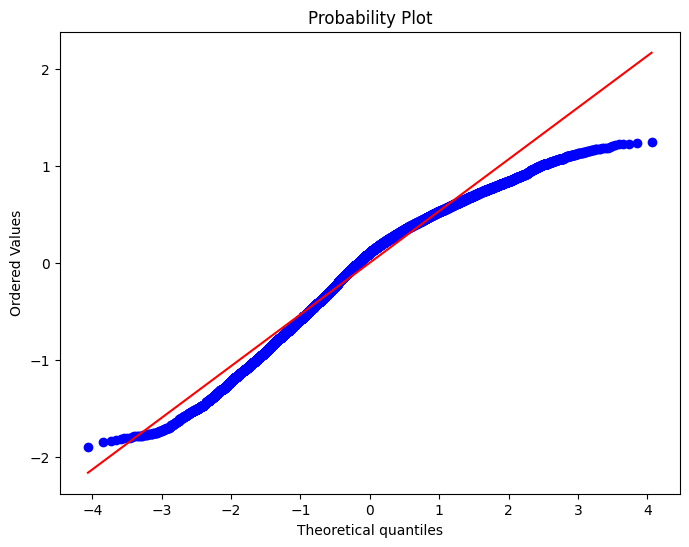

In [22]:
residuals=y_test-yhat
plt.figure(figsize=(8,6))
stats.probplot(residuals,dist='norm',plot=plt)
plt.show()
#tiene sesgo

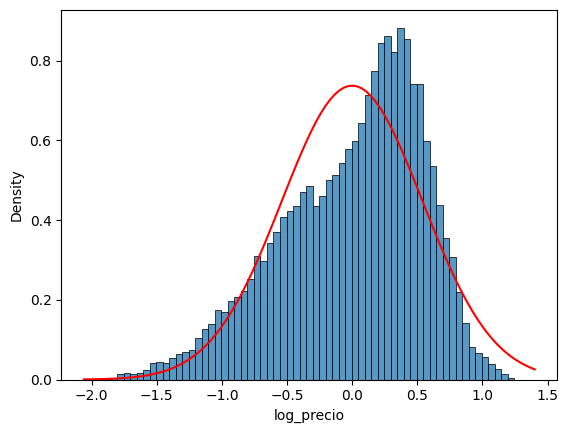

In [23]:
sns.histplot(
    x=residuals,
    stat='density',
)
media,std=np.mean(residuals),np.std(residuals)
xmin,xmax=plt.xlim()
x_teo=np.linspace(xmin,xmax,100)
y_teo=stats.norm.pdf(x_teo,media,std)
plt.plot(
    x_teo,y_teo,color='red'
)
plt.show()

In [24]:
residuals_z=(residuals-media)/std
print(stats.kstest(residuals_z,'norm'))
# los errores no son normales

KstestResult(statistic=np.float64(0.07728036773303226), pvalue=np.float64(1.9868774474365867e-148), statistic_location=np.float64(0.2487379998152338), statistic_sign=np.int8(-1))


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189922 entries, 0 to 189921
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ASSETID                        189922 non-null  str    
 1   PERIOD                         189922 non-null  int64  
 2   PRICE                          189922 non-null  int64  
 3   UNITPRICE                      189922 non-null  float64
 4   CONSTRUCTEDAREA                189922 non-null  int64  
 5   ROOMNUMBER                     189922 non-null  int64  
 6   BATHNUMBER                     189922 non-null  int64  
 7   HASTERRACE                     189922 non-null  bool   
 8   HASLIFT                        189922 non-null  bool   
 9   HASAIRCONDITIONING             189922 non-null  bool   
 10  AMENITYID                      189922 non-null  int64  
 11  HASPARKINGSPACE                189922 non-null  bool   
 12  ISPARKINGSPACEINCLUDEDINPRICE  189922 non

In [ ]:
#Analisis estadistico del efecto de tener ascensor en el precio
con_ascensor=df[df["HASLIFT"]==True]["log_precio"]
sin_ascensor=df[df["HASLIFT"]==False]["log_precio"]

alpha=0.05
con_ascensor_z = ( con_ascensor- con_ascensor.mean()) / con_ascensor.std()

stat_n, p_n = stats.kstest(con_ascensor_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")

sin_ascensor_z = ( sin_ascensor- sin_ascensor.mean()) / sin_ascensor.std()

stat_n, p_n = stats.kstest(sin_ascensor_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")


stat_var, p_var = stats.levene(con_ascensor, sin_ascensor)

print(f"Estadístico: {stat_var}")
print(f"p-value: {p_var} | Varianzas diferentes: {p_var < alpha}")


print(con_ascensor.std()**2)
print(sin_ascensor.std()**2)

In [48]:
#Analisis estadistico comparativa de las media de precios entre Madrid y Barcelona.

print(f"La media del precio de los pisos en Madrid es de: {df[df["CITYNAME"]=="Madrid"]["PRICE"].mean().round(0)}")
print(f"La media del precio de los pisos en Barcelona es de: {df[df["CITYNAME"]=="Barcelona"]["PRICE"].mean().round(0)}")

print(f"La media en base logaritmica del precio de los pisos en Madrid es de: {df[df["CITYNAME"]=="Madrid"]["log_precio"].mean().round(2)}")
print(f"La media en base logaritmica del precio de los pisos en Barcelona es de: {df[df["CITYNAME"]=="Barcelona"]["log_precio"].mean().round(2)}")


log_price_Madrid=df[df["CITYNAME"]=="Madrid"]["log_precio"]
log_price_Barcelona=df[df["CITYNAME"]=="Barcelona"]["log_precio"]

alpha=0.05
log_price_Madrid_z= ( log_price_Madrid- log_price_Madrid.mean()) / log_price_Madrid.std()

stat_n, p_n = stats.kstest(log_price_Madrid_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")

log_price_Barcelona_z = ( log_price_Barcelona- log_price_Barcelona.mean()) / log_price_Barcelona.std()

stat_n, p_n = stats.kstest(log_price_Barcelona_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")


stat_var, p_var = stats.levene(log_price_Madrid, log_price_Barcelona)

print(f"Estadístico: {stat_var}")
print(f"p-value: {p_var} | Varianzas diferentes: {p_var < alpha}")


print(log_price_Madrid.std()**2)
print(log_price_Barcelona.std()**2)
print(log_price_Madrid.mean())
print(log_price_Barcelona.mean())


t_stat, p_val = stats.ttest_ind(log_price_Madrid, log_price_Barcelona, equal_var=True)

print(f"Estadístico: {t_stat}")
print(f"Diferencia observada: {np.abs(log_price_Madrid.mean() - log_price_Barcelona.mean())}")
print(f"p-value: {p_val} | Medias diferentes: {p_val < alpha}")

La media del precio de los pisos en Madrid es de: 396112.0
La media del precio de los pisos en Barcelona es de: 395771.0
La media en base logaritmica del precio de los pisos en Madrid es de: 12.56
La media en base logaritmica del precio de los pisos en Barcelona es de: 12.71
Estadístico: 0.05549457278739106
p-value: 3.084418521418949e-254 | Normal: False
Estadístico: 0.036804724868842786
p-value: 8.426384015444508e-73 | Normal: False
Estadístico: 6220.178872106427
p-value: 0.0 | Varianzas diferentes: True
0.5780178341338721
0.32438402768835106
12.563613996005417
12.714148970998108
Estadístico: -42.039560380810556
Diferencia observada: 0.15053497499269142
p-value: 0.0 | Medias diferentes: True


In [ ]:
print(f"Estadístico: {t_stat}")
print(f"Diferencia observada: {abs(log_price_Madrid.mean() - log_price_Barcelona.mean())}")
print(f"p-value: {p_val} | Medias diferentes: {p_val < alpha}")

#En conclusión: 
#Los datos del precio en base logaritmica, aunque están proximas a ser una distribución normal, esttaditicamente no los son.
#Además las varianzas entre logaritmo de precios entre Madrid y Barcelona, son claramente distinitos. Esto compormente el resultado del T-Test.
#Como resultado del T-Test se obtiene que, aunque la media de precios, y log_precios es muy pequeña, la señal es muy devil por lo que, junto a los resultados de los test de
#Test de Levene y de Kolmogorov-Smirnov no puede sacar niguna conclusión sobre la similitud de la media de precios entre las 2 ciudades.
#Es muy posible que la semejanza sea casual por las muestras obtneidas.

Estadístico: -42.039560380810556
Diferencia observada: 0.15053497499269142
p-value: 0.0 | Medias diferentes: True
